In [1]:
import pandas as pd
import spacy
from collections import Counter

# CONFIGURATION
INPUT = "/home/ensai/Cours/PFE/Topic-modeling-with-NLP/data/makeorg_biodiversite.xlsx"
OUTPUT = "output.xlsx"
TEXT_COL = "Proposition"
NEW_COL = "Tokens_lemmas"
MODEL = "fr_core_news_lg" 

# READ DATA
df = pd.read_excel(INPUT)

if TEXT_COL not in df.columns:
    raise ValueError(f"Column '{TEXT_COL}' not found. Available: {list(df.columns)}")

# Remove leading "Il faut …"
df[TEXT_COL] = df[TEXT_COL].str.replace(r'^\s*Il faut\s+', '', case=False, regex=True)

# LOAD MODEL
nlp = spacy.load(MODEL)

# Stopwords personnalisés (plus sélectifs)
CUSTOM_STOPWORDS = {
    'être', 'avoir', 'faire', 'pouvoir', 'devoir', 'vouloir',
    'aller', 'mettre', 'prendre', 'dire', 'savoir', 'voir',
    'celui', 'celle', 'ceux', 'celles', 'ceci', 'cela',
    'le', 'la', 'les', 'un', 'une', 'des', 'du', 'de',
    'ce', 'cette', 'ces', 'mon', 'ma', 'mes', 'ton', 'ta', 'tes',
    'son', 'sa', 'ses', 'notre', 'nos', 'votre', 'vos', 'leur', 'leurs',
    'je', 'tu', 'il', 'elle', 'nous', 'vous', 'ils', 'elles',
    'me', 'te', 'se', 'lui', 'leur', 'en', 'y',
    'qui', 'que', 'quoi', 'dont', 'où',
    'et', 'ou', 'mais', 'donc', 'car', 'ni', 'or',
    'à', 'dans', 'par', 'pour', 'sous', 'sur', 'vers',
    'aussi', 'pas'
}

def doc_to_lemmas(doc):
    """
    Extrait les lemmes pertinents pour l'analyse sémantique
    Focus sur: NOUN, VERB, ADJ, ADV principalement
    """
    lemmas = []
    
    for tok in doc:
        # Skip ponctuation et espaces
        if tok.is_punct or tok.is_space:
            continue
        
        # Skip nombres
        if tok.like_num or tok.is_digit:
            continue
        
        # Skip tokens non-alphabétiques (sauf si composés avec tiret)
        if not tok.is_alpha and '-' not in tok.text:
            continue
        
        # Skip si trop court (souvent du bruit)
        if len(tok.text) < 3:
            continue
        
        # Filtrage par POS (Part-of-Speech)
        # Gardez les mots porteurs de sens
        if tok.pos_ not in ['NOUN', 'VERB', 'ADJ', 'PROPN', 'ADV']:
            continue
        
        # Lemmatisation
        lemma = tok.lemma_.lower().strip()
        
        # Skip stopwords personnalisés
        if lemma in CUSTOM_STOPWORDS:
            continue
        
        # Skip si le lemma est vide ou trop court après nettoyage
        if len(lemma) < 3:
            continue
        
        lemmas.append(lemma)
    
    return lemmas

# PROCESS TEXTS
print("Traitement des textes...")
texts = df[TEXT_COL].astype(str).fillna("").tolist()

# Utilisez parser pour avoir les POS tags corrects
docs = nlp.pipe(texts, disable=["ner"])  # Gardez le parser !

df[NEW_COL] = [doc_to_lemmas(doc) for doc in docs]

# Filtrer les propositions vides
df = df[df[NEW_COL].map(len) > 0].reset_index(drop=True)

print(f"{len(df)} propositions traitées")
print(f"\nExemples de lemmatisation:")
print(df[[TEXT_COL, NEW_COL]].head(10))

# Statistiques sur le vocabulaire
all_lemmas = [lemma for lemmas in df[NEW_COL] for lemma in lemmas]
vocab_size = len(set(all_lemmas))
avg_length = sum(len(lemmas) for lemmas in df[NEW_COL]) / len(df)

print(f"\n Statistiques:")
print(f"  - Vocabulaire total: {vocab_size} lemmes uniques")
print(f"  - Longueur moyenne: {avg_length:.1f} lemmes/proposition")
print(f"  - Total tokens: {len(all_lemmas)}")

# Top lemmes les plus fréquents
lemma_counts = Counter(all_lemmas)
print(f"\n Top 20 lemmes:")
for lemma, count in lemma_counts.most_common(20):
    print(f"  {lemma}: {count}")

Traitement des textes...
5554 propositions traitées

Exemples de lemmatisation:
                                         Proposition  \
0  favoriser le reboisement urbain afin de baisse...   
1  stopper l’érosion des haies (-23 500km par an)...   
2  stopper l&apos;importation de produits agricol...   
3  réintégrer les arbres et les haies dans l’agri...   
4  empêcher l&apos;importation de produits agrico...   
5  replanter des haies pour éviter l&apos;érosion...   
6  punir sévèrement ceux qui déversent des déchet...   
7  replanter des haies autour des champs afin de ...   
8  préserver, restaurer, maintenir en bon état éc...   
9  soutenir une agriculture protectrice du vivant...   

                                       Tokens_lemmas  
0  [favoriser, reboisement, urbain, afin, baisser...  
1  [stopper, érosion, haie, puissant, levier, tra...  
2  [stopper, produit, agricole, traiter, produit,...  
3  [réintégrer, arbre, haie, agriculture, produir...  
4  [empêcher, produit, agric

## Hyperparameter tuning 

We are taking a fixed window size of 14 to cover all the words of a sentence. Also we are taking negative sampling = 4. So we are tuning only the vector size and the number of epochs 


In [2]:
from gensim.models import Word2Vec
from collections import Counter
import numpy as np

SEED = 42
sentences = df[NEW_COL].tolist()

# ================================================
# 1) MOTS DE RÉFÉRENCE
# ================================================
# Définissez ici vos mots pertinents
reference_words = [
    'chasse', 
    'haie',
    'ville',
    'importation',
    'déchet',
    'plastique',
    'enfant', 
    'forêt',
    'animal',
    'nature',
    'police'

]

# ================================================
# 2) Hyperparameters 
# ================================================
vector_sizes = [50, 128,150]
epochs_list = [15, 20, 50]
sg_values = [0, 1]             # CBOW and Skip-gram
window = 14                    # fixed
negative = 4                   # fixed
# negatives = [4, 6, 10]

print("="*70)
print("GRID SEARCH WORD2VEC")
print("="*70)
print("Paramètres fixes:")
print(f"  - window: {window}")
print(f"  - negative: {negative}")
print(f"  - min_count: 2")
print("\nParamètres variables:")
print(f"  - vector_sizes: {vector_sizes}")
print(f"  - epochs: {epochs_list}")
print(f"  - sg: {sg_values} (0=CBOW, 1=Skip-gram)")
print(f"\nMots de référence: {reference_words}")
print("="*70)

# ================================================
# 3) GRID SEARCH
# ================================================
for vs in vector_sizes:
    for ep in epochs_list:
        for sg in sg_values:
            
            sg_name = "Skip-gram" if sg == 1 else "CBOW"
            
            print(f"\n\n{'='*70}")
            print(f"MODÈLE: vector_size={vs} | epochs={ep} | {sg_name}")
            print("="*70)

            model = Word2Vec(
                sentences=sentences,
                vector_size=vs,
                window=window,
                min_count=2,
                sg=sg,
                negative=negative,
                workers=4,
                epochs=ep,
                seed=SEED
            )
            
            # Afficher les mots similaires pour chaque mot de référence
            for word in reference_words:
                if word in model.wv:
                    try:
                        similar = model.wv.most_similar(word, topn=7)
                        print(f"  '{word}':")
                        for similar_word, similarity in similar:
                            print(f"    - {similar_word}: {similarity:.4f}")
                    except Exception as e:
                        print(f"  '{word}' -> Erreur: {e}")
                else:
                    print(f"  '{word}' -> [Absent du vocabulaire]")

print("\n\n" + "="*70)
print("GRID SEARCH TERMINÉ")
print("="*70)

GRID SEARCH WORD2VEC
Paramètres fixes:
  - window: 14
  - negative: 4
  - min_count: 2

Paramètres variables:
  - vector_sizes: [50, 128, 150]
  - epochs: [15, 20, 50]
  - sg: [0, 1] (0=CBOW, 1=Skip-gram)

Mots de référence: ['chasse', 'haie', 'ville', 'importation', 'déchet', 'plastique', 'enfant', 'forêt', 'animal', 'nature', 'police']


MODÈLE: vector_size=50 | epochs=15 | CBOW
  'chasse':
    - courre: 0.9741
    - cruel: 0.9719
    - pêche: 0.9567
    - strictement: 0.9506
    - déterrage: 0.9429
    - enclos: 0.9400
    - interdire: 0.9380
  'haie':
    - replanter: 0.9806
    - bocager: 0.9741
    - buisson: 0.9559
    - thuya: 0.9513
    - arbre: 0.9502
    - particulier: 0.9492
    - délimiter: 0.9491
  'ville':
    - jardin: 0.9795
    - végétaliser: 0.9789
    - parking: 0.9741
    - fleur: 0.9694
    - semer: 0.9690
    - arbuste: 0.9670
    - commune: 0.9647
  'importation':
    - viande: 0.9967
    - nocif: 0.9952
    - européen: 0.9951
    - alternative: 0.9950
    - con

Looking at the result vector size 150, epoch = 15, CBOW seems to be the best model. Capturing different aspects.
Why 150D and not 128D because 'police' has ethic meanings(Not suffering of semantic collapse because embeddings live in a higher dimension). 
Moreover 20+ epochs -> vectors will be more specific -> higher risk of overfitting; we see that we have a lower cosine similarity

Here is a function to display the top n similar words for any words

In [3]:
best_model = Word2Vec(
    sentences=sentences,
    vector_size=150,
    window=14,
    min_count=2,
    sg=0,
    negative=4,
    workers=4,
    epochs=15,
    seed=SEED
)

In [4]:
def get_similar_words(model, word, top_n=7):
    """
    Trouve les mots les plus similaires à un mot donné.
    
    Parameters:
    -----------
    model : Word2Vec
        Le modèle Word2Vec entraîné
    word : str
        Le mot pour lequel on cherche les similaires
    top_n : int, default=7
        Nombre de mots similaires à retourner
    
    Returns:
    --------
    list of tuples or None
        Liste de tuples (mot, similarité) ou None si le mot n'existe pas
    
    """
    if word not in model.wv:
        print(f"Le mot '{word}' n'existe pas dans le vocabulaire du modèle.")
        return None
    
    try:
        similar = model.wv.most_similar(word, topn=top_n)
        return similar
    except Exception as e:
        print(f"Erreur lors de la recherche: {e}")
        return None
    
similar = get_similar_words(best_model, 'chasse')
if similar:
    for word, score in similar:
        print(f"{word}:{score:.4f}")

cruel:0.9838
courre:0.9786
déterrage:0.9761
pêche:0.9705
interdire:0.9685
trophée:0.9677
dimanche:0.9615


## Clustering and then Visualizing

In [5]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

# ========================================
# 1. CONVERSION DES PROPOSITIONS EN VECTEURS
# ========================================

def proposition_to_vector(lemmas, model):
    """
    Moyenne des vecteurs de mots (avec gestion des mots absents)
    """
    vectors = []
    for lemma in lemmas: 
        
        if lemma in model.wv:
            vectors.append(model.wv[lemma])
    
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)

# Créer les vecteurs de propositions dans l'espace 150D
print("\n" + "="*60)
print("CRÉATION DES VECTEURS DE PROPOSITIONS (150D)")
print("="*60)
X = np.array([proposition_to_vector(lemmas, model) for lemmas in sentences])
print(f"Shape des embeddings: {X.shape}")


CRÉATION DES VECTEURS DE PROPOSITIONS (150D)
Shape des embeddings: (5554, 150)



RECHERCHE DU NOMBRE OPTIMAL DE CLUSTERS
  k=5: silhouette=0.035
  k=6: silhouette=0.033
  k=7: silhouette=0.029
  k=8: silhouette=0.031
  k=9: silhouette=0.032
  k=10: silhouette=0.034
  k=11: silhouette=0.033
  k=12: silhouette=0.034
  k=13: silhouette=0.037
  k=14: silhouette=0.035
  k=15: silhouette=0.038
  k=16: silhouette=0.037
  k=17: silhouette=0.037
  k=18: silhouette=0.041
  k=19: silhouette=0.041
  k=20: silhouette=0.036


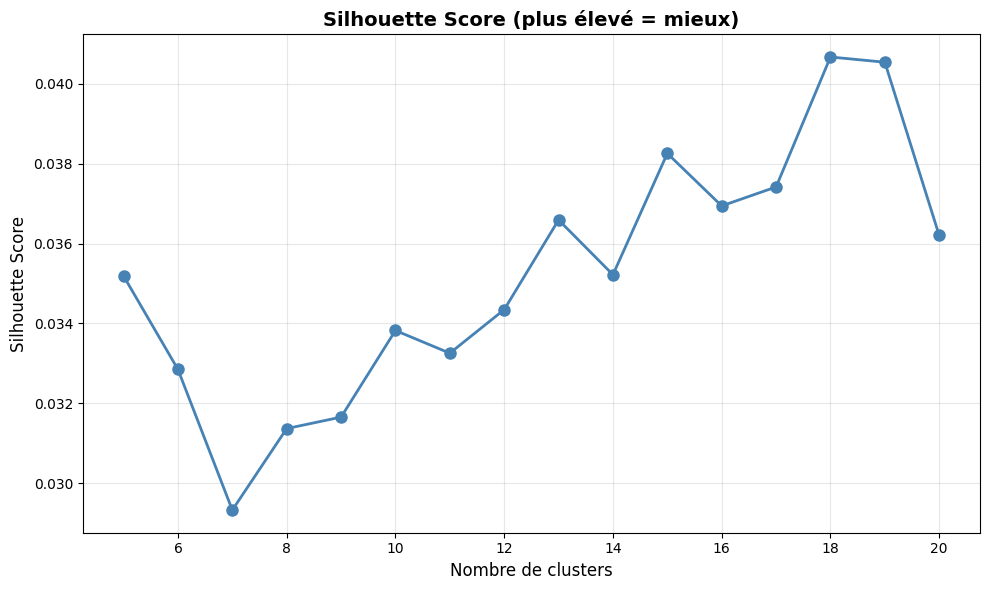


MEILLEUR K: 18
Score Silhouette: 0.041


In [6]:
# ========================================
# 2. CLUSTERING DANS L'ESPACE 128D
# ========================================

print("\n" + "="*60)
print("RECHERCHE DU NOMBRE OPTIMAL DE CLUSTERS")
print("="*60)
silhouette_scores = []
K_range = range(5, 21)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X)
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)
    print(f"  k={k}: silhouette={sil_score:.3f}")

# Plot silhouette score
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Nombre de clusters', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score (plus élevé = mieux)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('silhouette_score.png', dpi=300)
plt.show()

# Choisir le meilleur k
best_k = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print(f"\n{'='*60}")
print(f"MEILLEUR K: {best_k}")
print(f"Score Silhouette: {best_score:.3f}")
print("="*60)


In [10]:
# ========================================
# 3. CLUSTERING FINAL DANS L'ESPACE 150D
# ========================================
best_k = 20
print(f"\nClustering final avec k={best_k} dans l'espace 150D...")
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10, max_iter=300)
df['cluster'] = kmeans_final.fit_predict(X)

# Afficher la distribution des clusters
cluster_counts = df['cluster'].value_counts().sort_index()
print("\nDistribution des clusters:")
for cluster_id, count in cluster_counts.items():
    print(f"  Cluster {cluster_id}: {count} propositions ({count/len(df)*100:.1f}%)")


Clustering final avec k=20 dans l'espace 150D...

Distribution des clusters:
  Cluster 0: 144 propositions (2.6%)
  Cluster 1: 453 propositions (8.2%)
  Cluster 2: 215 propositions (3.9%)
  Cluster 3: 341 propositions (6.1%)
  Cluster 4: 140 propositions (2.5%)
  Cluster 5: 253 propositions (4.6%)
  Cluster 6: 248 propositions (4.5%)
  Cluster 7: 378 propositions (6.8%)
  Cluster 8: 264 propositions (4.8%)
  Cluster 9: 315 propositions (5.7%)
  Cluster 10: 257 propositions (4.6%)
  Cluster 11: 142 propositions (2.6%)
  Cluster 12: 185 propositions (3.3%)
  Cluster 13: 287 propositions (5.2%)
  Cluster 14: 195 propositions (3.5%)
  Cluster 15: 431 propositions (7.8%)
  Cluster 16: 222 propositions (4.0%)
  Cluster 17: 352 propositions (6.3%)
  Cluster 18: 379 propositions (6.8%)
  Cluster 19: 353 propositions (6.4%)


In [11]:
# ========================================
# 4. RÉDUCTION DE DIMENSIONNALITÉ POUR VISUALISATION 2D
# ========================================
import umap
print("\n" + "="*60)
print("RÉDUCTION DE DIMENSIONNALITÉ AVEC UMAP")
print("="*60)

print("Application d'UMAP...")
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1, metric='cosine')
X_2d_umap = umap_reducer.fit_transform(X)



RÉDUCTION DE DIMENSIONNALITÉ AVEC UMAP
Application d'UMAP...


/home/ensai/Cours/PFE/Topic-modeling-with-NLP/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/ensai/Cours/PFE/Topic-modeling-with-NLP/.venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


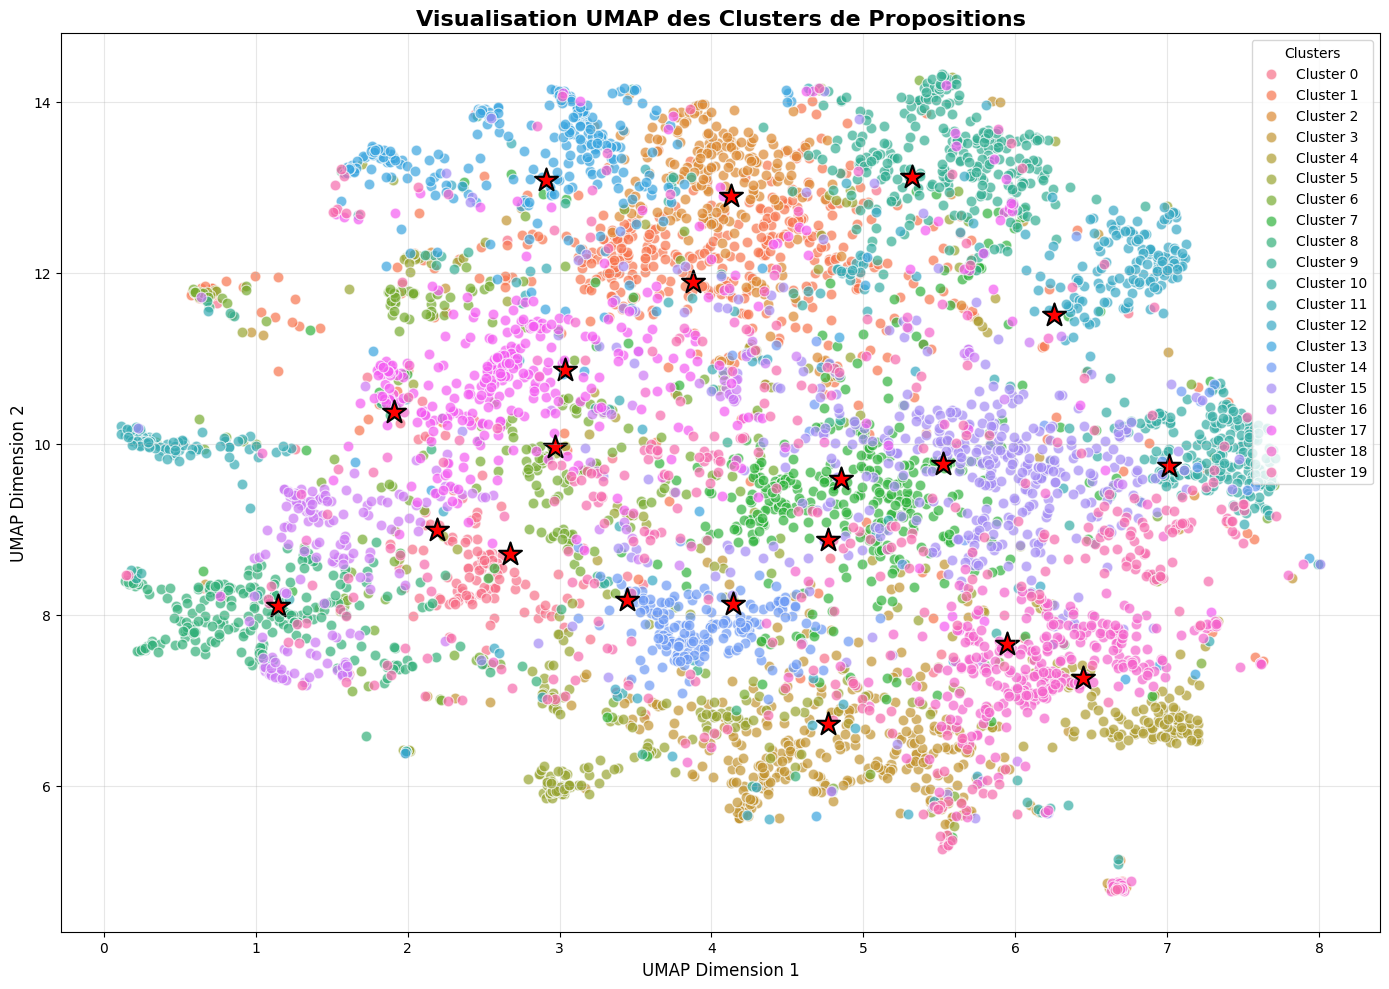

In [12]:
# ========================================
# 5. VISUALISATION 2D AVEC UMAP
# ========================================

plt.figure(figsize=(14, 10))
colors = sns.color_palette("husl", best_k)

for cluster_id in range(best_k):
    mask = df['cluster'] == cluster_id
    plt.scatter(
        X_2d_umap[mask, 0], 
        X_2d_umap[mask, 1],
        c=[colors[cluster_id]], 
        label=f'Cluster {cluster_id}',
        alpha=0.7,
        s=60,
        edgecolors='white',
        linewidth=0.8
    )

plt.title('Visualisation UMAP des Clusters de Propositions', fontsize=16, fontweight='bold')
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.legend(loc='best', frameon=True, fontsize=10, title='Clusters')
plt.grid(True, alpha=0.3)

# Ajouter les centroïdes des clusters en 2D
centroids_2d = []
for cluster_id in range(best_k):
    cluster_points = X_2d_umap[df['cluster'] == cluster_id]
    centroid = cluster_points.mean(axis=0)
    centroids_2d.append(centroid)
    plt.scatter(centroid[0], centroid[1], 
                marker='*', s=300, c='red', 
                edgecolors='black', linewidth=1.5, 
                label=f'Centroïde {cluster_id}' if cluster_id == 0 else "")

plt.tight_layout()
plt.savefig('clusters_visualization_umap.png', dpi=300, bbox_inches='tight')
plt.show()


In [13]:
# ========================================
# 6. ANALYSE DÉTAILLÉE DES CLUSTERS
# ========================================

print("\n" + "="*60)
print("ANALYSE DÉTAILLÉE DES CLUSTERS")
print("="*60)

# Créer un dictionnaire pour stocker les résultats d'analyse
cluster_analysis = {}

for cluster_id in range(best_k):
    # Récupérer les propositions du cluster
    cluster_propositions = df[df['cluster'] == cluster_id]
    
    # 1. Mots les plus fréquents
    all_words = []
    for lemmas in cluster_propositions['Tokens_lemmas']:  # Remplacez par le nom de votre colonne de lemmes
        all_words.extend(lemmas)
    
    word_counts = Counter(all_words)
    top_words = word_counts.most_common(15)
    
    # 2. Thème principal (basé sur les mots les plus fréquents)
    theme_keywords = [word for word, count in top_words[:5]]
    
    # 3. Exemples de phrases (les propositions originales)
    # Supposons que vous avez une colonne 'Proposition' avec le texte original
    example_propositions = []
    if 'Proposition' in df.columns:
        examples = cluster_propositions['Proposition'].head(3).tolist()
        example_propositions = examples
    
    # Stocker l'analyse
    cluster_analysis[cluster_id] = {
        'size': len(cluster_propositions),
        'top_words': top_words[:10],  # Top 10 mots
        'theme_keywords': theme_keywords,
        'examples': example_propositions,
        'centroid_2d': centroids_2d[cluster_id]
    }
    
    # Afficher l'analyse pour ce cluster
    print(f"\n{'─'*80}")
    print(f"CLUSTER {cluster_id} ({len(cluster_propositions)} propositions, {len(cluster_propositions)/len(df)*100:.1f}%)")
    print(f"{'─'*80}")
    
    print(f" THÈME PRINCIPAL: {', '.join(theme_keywords)}")
    
    print(f"\n MOTS LES PLUS FRÉQUENTS:")
    for i, (word, count) in enumerate(cluster_analysis[cluster_id]['top_words'], 1):
        print(f"   {i:2d}. {word:15s} ({count} occurrences)")
    
    if cluster_analysis[cluster_id]['examples']:
        print(f"\n EXEMPLES DE PROPOSITIONS:")
        for i, example in enumerate(cluster_analysis[cluster_id]['examples'], 1):
            # Limiter la longueur de l'exemple pour une meilleure lisibilité
            if len(example) > 120:
                example = example[:117] + "..."
            print(f"   {i}. {example}")


ANALYSE DÉTAILLÉE DES CLUSTERS

────────────────────────────────────────────────────────────────────────────────
CLUSTER 0 (144 propositions, 2.6%)
────────────────────────────────────────────────────────────────────────────────
 THÈME PRINCIPAL: pêche, interdire, mer, protéger, marin

 MOTS LES PLUS FRÉQUENTS:
    1. pêche           (69 occurrences)
    2. interdire       (50 occurrences)
    3. mer             (33 occurrences)
    4. protéger        (32 occurrences)
    5. marin           (31 occurrences)
    6. zone            (20 occurrences)
    7. tout            (16 occurrences)
    8. plus            (15 occurrences)
    9. détruire        (14 occurrences)
   10. marine          (14 occurrences)

 EXEMPLES DE PROPOSITIONS:
   1. améliorer la réglementation sur la préservation des espèces marines menacées et les aires marines protégées (AMP)
   2. interdire les supertrawlers/les méthodes de pêche destructrices et non séléctives
   3. aider les pêcheurs au chalut à faire une tra

# Thématiques principales par cluster

## Cluster 0
**Réduction du plastique et des emballages**  
(Consigne, verre, suppression du suremballage)

## Cluster 1
**Transition agroécologique et agriculture biologique**  
(Agriculture durable, biodiversité, pratiques agricoles)

## Cluster 2
**Interdiction des pesticides et des importations non conformes**  
(Normes environnementales, produits chimiques)

## Cluster 3
**Réduction de l’élevage intensif et de la consommation de viande**

## Cluster 4
**Protection de la faune locale face aux animaux domestiques**  
(Chats, oiseaux, stérilisation, limitation des impacts)

## Cluster 5
**Lutte contre les déchets abandonnés et les décharges sauvages**

## Cluster 6
**Interdiction ou régulation stricte de la chasse et de la pêche destructrice**

## Cluster 7
**Gestion durable et protection de la ressource en eau**

## Cluster 8
**Protection et restauration des espaces naturels et zones protégées**

## Cluster 9
**Valorisation des fruits et légumes locaux, de saison et hors normes**

## Cluster 10
**Urbanisme durable et construction respectueuse de l’environnement**  
(Limitation de l’artificialisation, végétalisation, solaire)

## Cluster 11
**Développement des espaces verts et de la biodiversité en ville**

## Cluster 12
**Plantation et protection des arbres, haies et bocages**

## Cluster 13
**Éducation et sensibilisation des enfants à la nature et à la biodiversité**

## Cluster 14
**Protection des espèces animales sauvages et de la faune**

## Cluster 15
**Réduction des nuisances humaines pour la faune**  
(Éclairage nocturne, routes, infrastructures)

## Cluster 16
**Actions transversales pour la protection de la biodiversité**  
(Entreprises, citoyens, politiques publiques)

## Cluster 17
**Réduction de l’impact environnemental des transports et de l’énergie**

## Cluster 18
**Protection des forêts et fin des pratiques forestières destructrices**



VISUALISATION DES MOTS CLÉS PAR CLUSTER


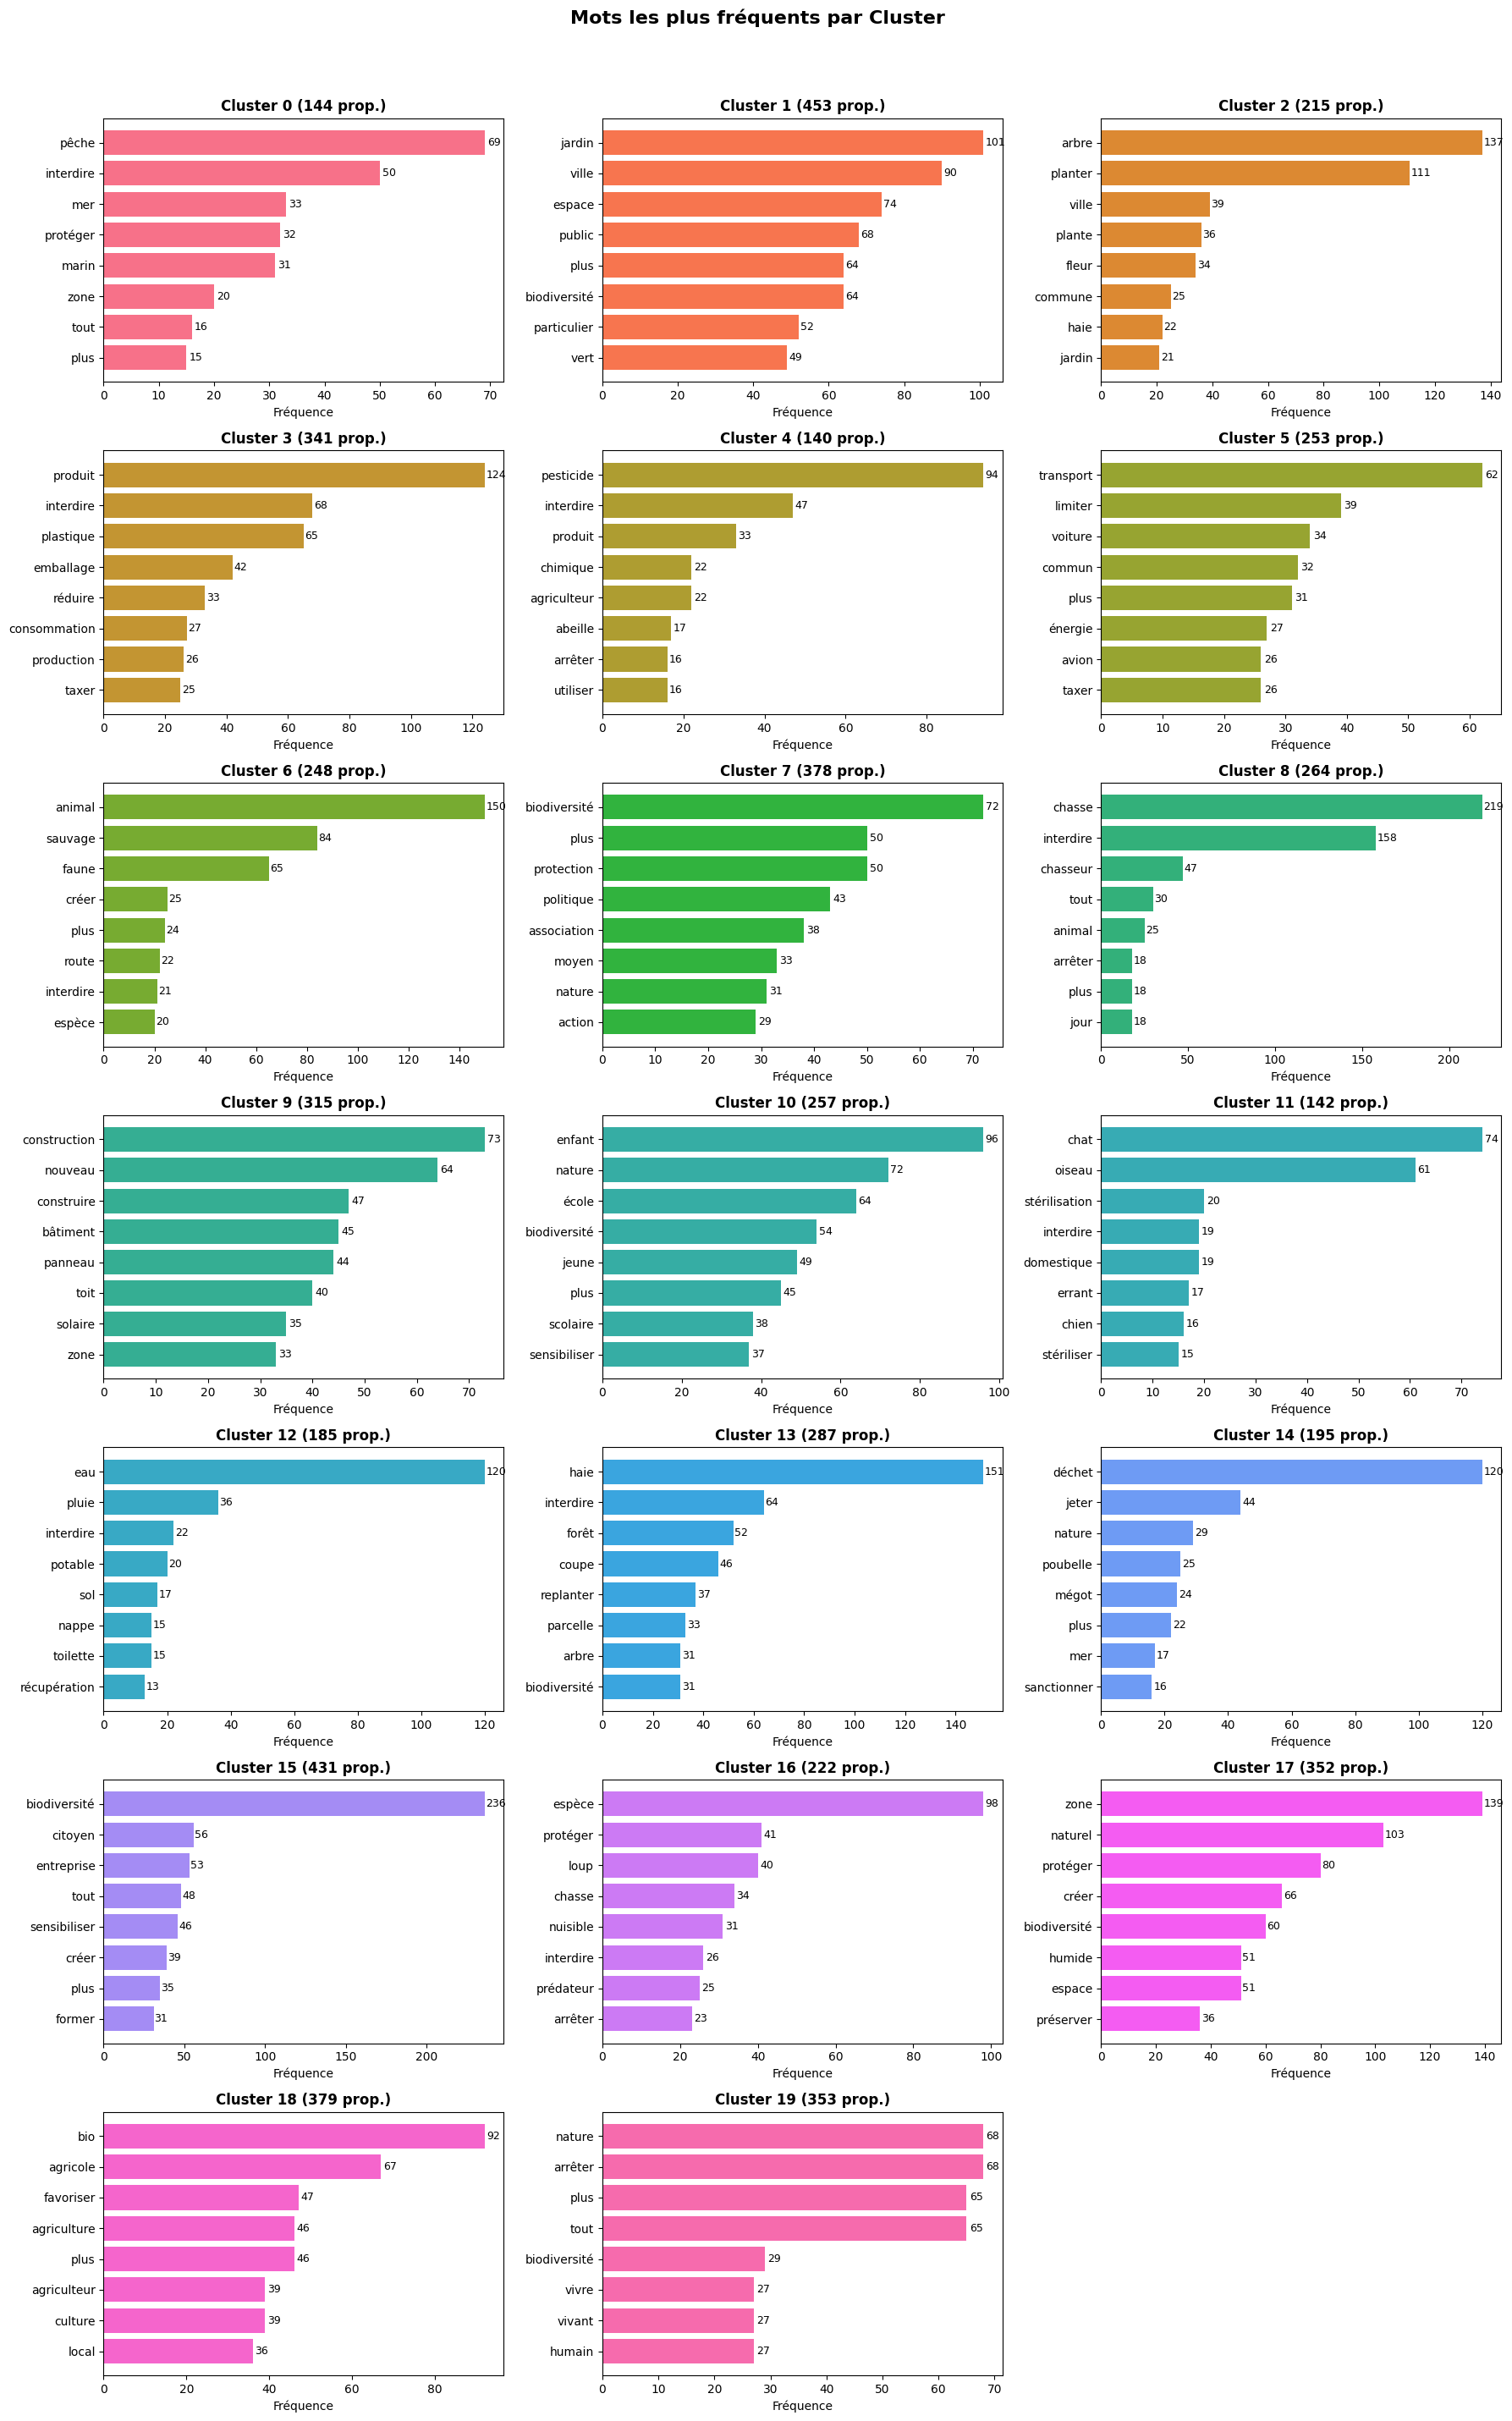


RÉSUMÉ DES CLUSTERS

 TABLEAU RÉCAPITULATIF:
----------------------------------------------------------------------------------------------------
Cluster  Taille   %        Thème principal                          Top 3 mots                    
----------------------------------------------------------------------------------------------------
0        144      2.6%     pêche, interdire, mer, protéger, marin   pêche, interdire, mer         
1        453      8.2%     jardin, ville, espace, public, plus      jardin, ville, espace         
2        215      3.9%     arbre, planter, ville, plante, fleur     arbre, planter, ville         
3        341      6.1%     produit, interdire, plastique, emballage, réduire produit, interdire, plastique 
4        140      2.5%     pesticide, interdire, produit, chimique, agriculteur pesticide, interdire, produit 
5        253      4.6%     transport, limiter, voiture, commun, plus transport, limiter, voiture   
6        248      4.5%     animal, sa

In [14]:
# ========================================
# 7. VISUALISATION DES MOTS CLÉS PAR CLUSTER
# ========================================

print("\n" + "="*60)
print("VISUALISATION DES MOTS CLÉS PAR CLUSTER")
print("="*60)

# Créer une visualisation des top mots par cluster
fig, axes = plt.subplots(int(np.ceil(best_k/3)), 3, figsize=(18, 4*int(np.ceil(best_k/3))))
axes = axes.flatten()

for cluster_id in range(best_k):
    # Récupérer les top mots et leurs fréquences
    words = [word for word, count in cluster_analysis[cluster_id]['top_words'][:8]]
    counts = [count for word, count in cluster_analysis[cluster_id]['top_words'][:8]]
    
    ax = axes[cluster_id]
    bars = ax.barh(words, counts, color=colors[cluster_id])
    ax.set_title(f'Cluster {cluster_id} ({cluster_analysis[cluster_id]["size"]} prop.)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Fréquence')
    ax.invert_yaxis()  # Afficher le mot le plus fréquent en haut
    
    # Ajouter les valeurs sur les barres
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{int(width)}', ha='left', va='center', fontsize=9)

# Cacher les axes inutilisés
for i in range(best_k, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Mots les plus fréquents par Cluster', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cluster_keywords.png', dpi=300, bbox_inches='tight')
plt.show()

# ========================================
# 8. SAUVEGARDER LES DONNÉES ANALYSÉES
# ========================================

# Ajouter les coordonnées UMAP au dataframe
df['umap_x'] = X_2d_umap[:, 0]
df['umap_y'] = X_2d_umap[:, 1]

# Créer un résumé des clusters
print("\n" + "="*60)
print("RÉSUMÉ DES CLUSTERS")
print("="*60)

summary_df = []
for cluster_id, analysis in cluster_analysis.items():
    summary_df.append({
        'Cluster': cluster_id,
        'Taille': analysis['size'],
        'Pourcentage': f"{analysis['size']/len(df)*100:.1f}%",
        'Thème principal': ', '.join(analysis['theme_keywords']),
        'Top 3 mots': ', '.join([word for word, count in analysis['top_words'][:3]])
    })

# Afficher le tableau récapitulatif
print("\n TABLEAU RÉCAPITULATIF:")
print("-" * 100)
print(f"{'Cluster':<8} {'Taille':<8} {'%':<8} {'Thème principal':<40} {'Top 3 mots':<30}")
print("-" * 100)
for row in summary_df:
    print(f"{row['Cluster']:<8} {row['Taille']:<8} {row['Pourcentage']:<8} {row['Thème principal']:<40} {row['Top 3 mots']:<30}")

# Sauvegarder le dataframe enrichi
df.to_csv('propositions_clusters_analyses.csv', index=False)
print(f"\n Données sauvegardées dans 'propositions_clusters_analyses.csv'")

print("\n" + "="*60)
print("TERMINÉ!")
print("="*60)
print(f" Clustering effectué avec {best_k} clusters")
print(f" Visualisation UMAP générée")
print(f" Thèmes principaux identifiés pour chaque cluster")
print(f" Exemples de propositions extraits")
print(f" Données enrichies sauvegardées")

## Dimension reduction then clustering(Not the best)


CLUSTERING APRÈS RÉDUCTION 2D (UMAP)
✓ Embeddings créés: (5554, 150)

----------------------------------------
RÉDUCTION DE DIMENSION AVEC UMAP
----------------------------------------


/home/ensai/Cours/PFE/Topic-modeling-with-NLP/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Réduction UMAP terminée: (5554, 2)

----------------------------------------
RECHERCHE DU NOMBRE OPTIMAL DE CLUSTERS (2D)
----------------------------------------
  k=3: silhouette=0.412, inertia=18397
  k=4: silhouette=0.417, inertia=12931
  k=5: silhouette=0.377, inertia=10598
  k=6: silhouette=0.377, inertia=8917
  k=7: silhouette=0.378, inertia=7553
  k=8: silhouette=0.387, inertia=6471
  k=9: silhouette=0.379, inertia=5757
  k=10: silhouette=0.387, inertia=5147
  k=11: silhouette=0.385, inertia=4614
  k=12: silhouette=0.389, inertia=4190
  k=13: silhouette=0.394, inertia=3811
  k=14: silhouette=0.398, inertia=3519
  k=15: silhouette=0.398, inertia=3253

✓ Meilleur k: 4 (score silhouette: 0.417)


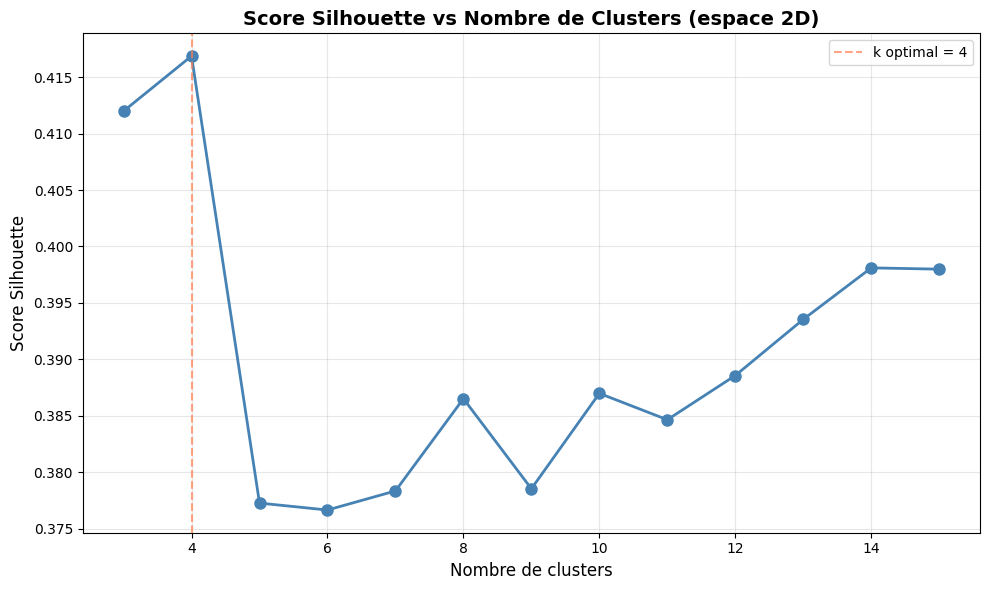


----------------------------------------
CLUSTERING FINAL AVEC k=4 (espace 2D)
----------------------------------------

Distribution des clusters:
  Cluster 0: 1202 propositions (21.6%)
  Cluster 1: 1287 propositions (23.2%)
  Cluster 2: 1748 propositions (31.5%)
  Cluster 3: 1317 propositions (23.7%)


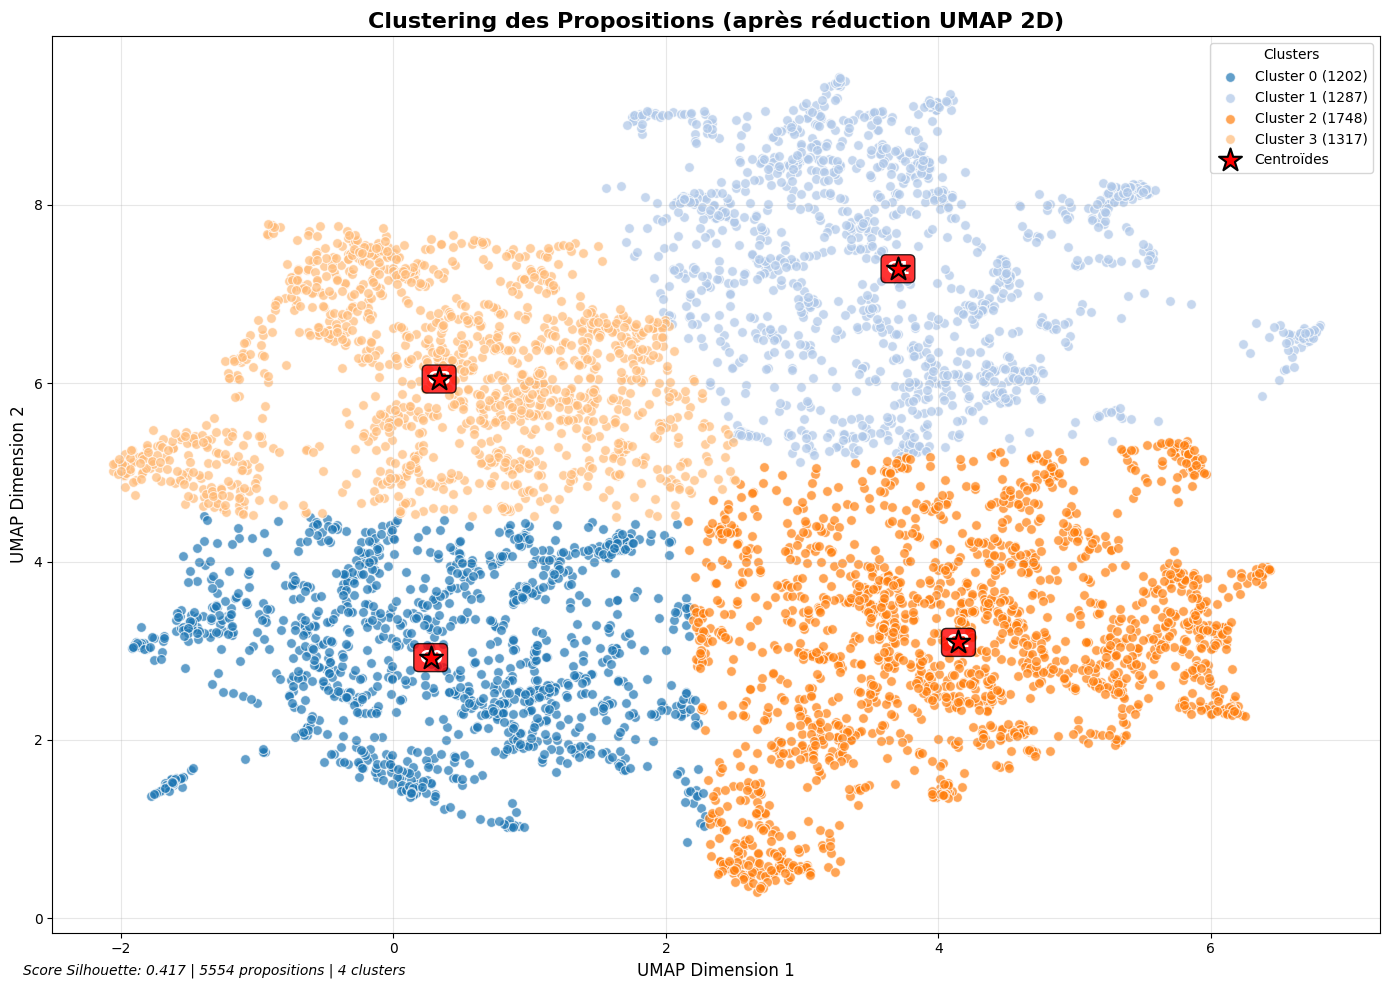


ANALYSE DÉTAILLÉE DES CLUSTERS

────────────────────────────────────────────────────────────────────────────────
📊 CLUSTER 0 (1202 propositions, 21.6%)
────────────────────────────────────────────────────────────────────────────────
📌 MOTS-CLÉS PRINCIPAUX:
   produit (186), interdire (156), plus (123), agriculture (104), 
   bio (100), pesticide (97), arrêter (89), biodiversité (88), 
   tout (86), plastique (79), agricole (75), agriculteur (72), 

🎯 THÈME PRINCIPAL: produit, interdire, plus, agriculture, bio

💡 EXEMPLES DE PROPOSITIONS:
   1. stopper l'importation de produits agricoles traités avec des produits interdits en France
   2. empêcher l'importation de produits agricoles qui sont traités avec des produits interdits en France
   3. soutenir une agriculture protectrice du vivant permettant une alimentation saine, locale, pour tous

────────────────────────────────────────────────────────────────────────────────
📊 CLUSTER 1 (1287 propositions, 23.2%)
──────────────────────────

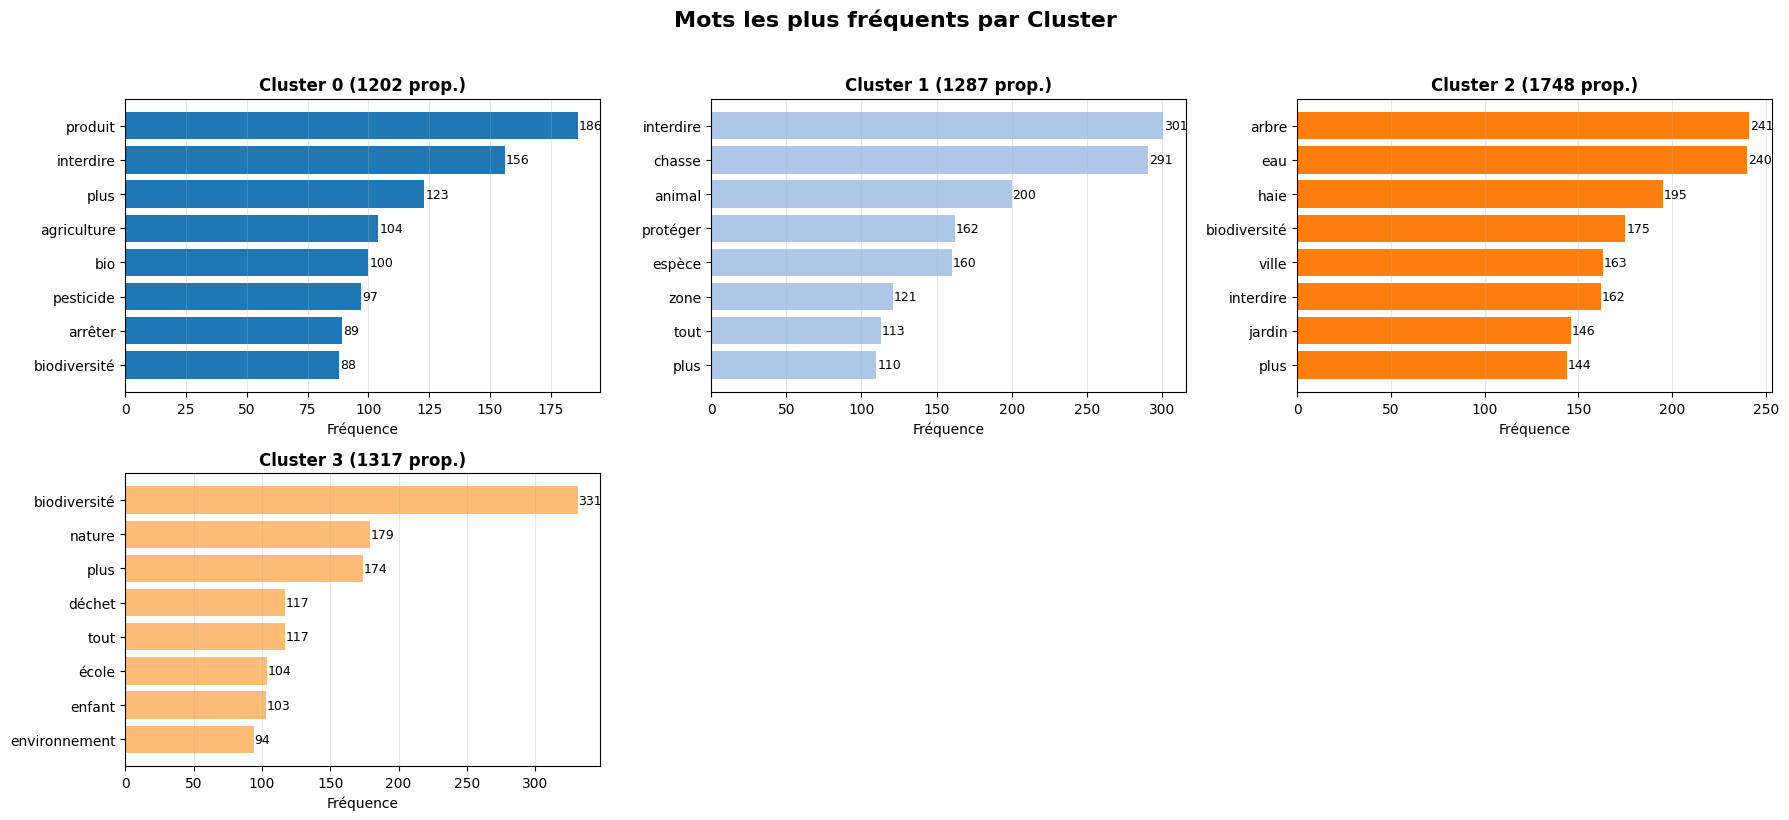


DISTANCES ENTRE CENTROÏDES DES CLUSTERS


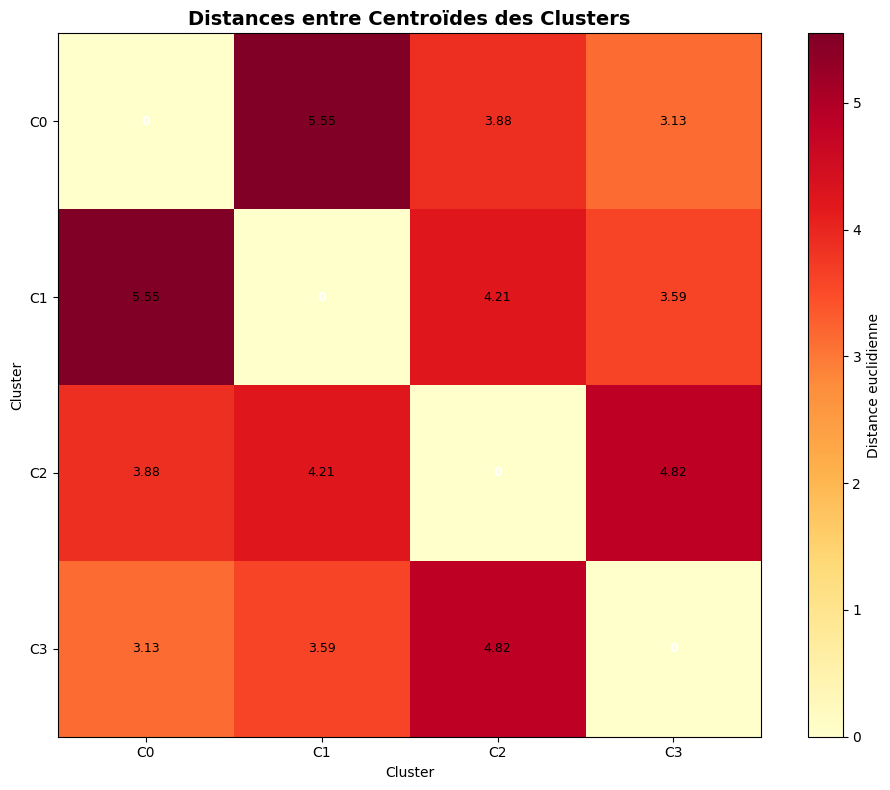


✓ Distances entre clusters (plus petit = plus similaires):
  Cluster 0: plus proche de C3 (3.13), plus éloigné de C1 (5.55)
  Cluster 1: plus proche de C3 (3.59), plus éloigné de C0 (5.55)
  Cluster 2: plus proche de C0 (3.88), plus éloigné de C3 (4.82)
  Cluster 3: plus proche de C0 (3.13), plus éloigné de C2 (4.82)

SAUVEGARDE DES RÉSULTATS
✓ Résultats sauvegardés dans 'propositions_clusters_2d.csv'
✓ Colonnes ajoutées: 'cluster', 'umap_x', 'umap_y', 'dist_to_centroid'

📋 RÉSUMÉ DES CLUSTERS:
----------------------------------------------------------------------------------------------------
Cluster  Taille   %        Thème principal                          Centroïde (x,y)     
----------------------------------------------------------------------------------------------------
0        1202     21.6%    produit, interdire, plus                 (0.27, 2.92)
1        1287     23.2%    interdire, chasse, animal                (3.70, 7.29)
2        1748     31.5%    arbre, eau, haie   

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import umap.umap_ as umap
import pandas as pd
from scipy.spatial import distance

# ========================================
# 1. CONVERSION DES PROPOSITIONS EN VECTEURS
# ========================================

def proposition_to_vector(lemmas, model):
    """
    Moyenne des vecteurs de mots (avec gestion des mots absents)
    """
    vectors = []
    for lemma in lemmas:
        if lemma in model.wv:
            vectors.append(model.wv[lemma])
    
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)

print("\n" + "="*60)
print("CLUSTERING APRÈS RÉDUCTION 2D (UMAP)")
print("="*60)

# Créer les vecteurs de propositions
X = np.array([proposition_to_vector(lemmas, model) for lemmas in sentences])
print(f"✓ Embeddings créés: {X.shape}")

# ========================================
# 2. RÉDUCTION EN 2D AVEC UMAP
# ========================================

print("\n" + "-"*40)
print("RÉDUCTION DE DIMENSION AVEC UMAP")
print("-"*40)

umap_reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    n_epochs=200
)

X_2d = umap_reducer.fit_transform(X)
print(f"✓ Réduction UMAP terminée: {X_2d.shape}")

# ========================================
# 3. RECHERCHE DU NOMBRE OPTIMAL DE CLUSTERS
# ========================================

print("\n" + "-"*40)
print("RECHERCHE DU NOMBRE OPTIMAL DE CLUSTERS (2D)")
print("-"*40)

silhouette_scores = []
K_range = range(3, 16)  # Test de 3 à 15 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_2d)
    
    if len(np.unique(labels)) > 1:
        sil_score = silhouette_score(X_2d, labels)
    else:
        sil_score = 0
        
    silhouette_scores.append(sil_score)
    print(f"  k={k}: silhouette={sil_score:.3f}, inertia={kmeans.inertia_:.0f}")

# Trouver le meilleur k
best_k = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print(f"\n✓ Meilleur k: {best_k} (score silhouette: {best_score:.3f})")

# Visualisation des scores silhouette
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.axvline(x=best_k, color='coral', linestyle='--', alpha=0.7, label=f'k optimal = {best_k}')
plt.xlabel('Nombre de clusters', fontsize=12)
plt.ylabel('Score Silhouette', fontsize=12)
plt.title('Score Silhouette vs Nombre de Clusters (espace 2D)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('silhouette_scores_2d.png', dpi=300)
plt.show()

# ========================================
# 4. CLUSTERING DANS L'ESPACE 2D
# ========================================

print(f"\n" + "-"*40)
print(f"CLUSTERING FINAL AVEC k={best_k} (espace 2D)")
print("-"*40)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10, max_iter=300)
df['cluster_2d'] = kmeans.fit_predict(X_2d)
centroids_2d = kmeans.cluster_centers_

# Distribution des clusters
cluster_counts = df['cluster_2d'].value_counts().sort_index()
print("\nDistribution des clusters:")
for cluster_id, count in cluster_counts.items():
    print(f"  Cluster {cluster_id}: {count} propositions ({count/len(df)*100:.1f}%)")

# ========================================
# 5. VISUALISATION DES CLUSTERS 2D
# ========================================

plt.figure(figsize=(14, 10))
colors = sns.color_palette("tab20", best_k)

# Tracer chaque cluster
for cluster_id in range(best_k):
    mask = df['cluster_2d'] == cluster_id
    plt.scatter(
        X_2d[mask, 0], 
        X_2d[mask, 1],
        c=[colors[cluster_id]], 
        label=f'Cluster {cluster_id} ({cluster_counts[cluster_id]})',
        alpha=0.7,
        s=50,
        edgecolors='white',
        linewidth=0.8
    )

# Tracer les centroïdes
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], 
            marker='*', s=300, c='red', 
            edgecolors='black', linewidth=1.5, 
            label='Centroïdes', zorder=10)

# Ajouter des labels pour les centroïdes
for i, centroid in enumerate(centroids_2d):
    plt.text(centroid[0], centroid[1], f'C{i}', 
             fontsize=12, fontweight='bold', 
             ha='center', va='center', 
             color='white', bbox=dict(boxstyle='round,pad=0.3', 
                                     facecolor='red', alpha=0.8))

plt.title('Clustering des Propositions (après réduction UMAP 2D)', 
          fontsize=16, fontweight='bold')
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.legend(loc='best', frameon=True, fontsize=10, title='Clusters')
plt.grid(True, alpha=0.3)

# Ajouter des annotations pour la qualité du clustering
sil_final = silhouette_score(X_2d, df['cluster_2d'])
plt.figtext(0.02, 0.02, f'Score Silhouette: {sil_final:.3f} | {len(df)} propositions | {best_k} clusters', 
            fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('clusters_2d_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# ========================================
# 6. ANALYSE DES CLUSTERS
# ========================================

print("\n" + "="*60)
print("ANALYSE DÉTAILLÉE DES CLUSTERS")
print("="*60)

# Fonction pour extraire les top mots d'un cluster
def get_cluster_top_words(df, cluster_id, n_words=15):
    cluster_df = df[df['cluster_2d'] == cluster_id]
    
    # Concaténer tous les lemmes du cluster
    all_words = []
    for lemmas in cluster_df['Tokens_lemmas']:  # Remplacez par votre colonne de lemmes
        all_words.extend(lemmas)
    
    # Compter les occurrences
    word_counts = Counter(all_words)
    
    # Filtrer les mots trop courts ou non significatifs
    filtered_counts = {word: count for word, count in word_counts.items() 
                      if len(word) > 2 and word not in ['le', 'la', 'les', 'de', 'des', 'un', 'une', 'et']}
    
    # Top n mots
    top_words = Counter(filtered_counts).most_common(n_words)
    return top_words

# Fonction pour extraire des exemples de propositions
def get_cluster_examples(df, cluster_id, n_examples=5):
    cluster_df = df[df['cluster_2d'] == cluster_id]
    
    # Prendre les propositions proches du centroïde
    examples = []
    
    # Si nous avons des propositions originales
    if 'Proposition' in cluster_df.columns:
        # Prendre un échantillon représentatif
        examples = cluster_df['Proposition'].head(n_examples).tolist()
    
    return examples

# Analyser chaque cluster
for cluster_id in sorted(df['cluster_2d'].unique()):
    cluster_df = df[df['cluster_2d'] == cluster_id]
    cluster_size = len(cluster_df)
    
    print(f"\n{'─'*80}")
    print(f" CLUSTER {cluster_id} ({cluster_size} propositions, {cluster_size/len(df)*100:.1f}%)")
    print(f"{'─'*80}")
    
    # 1. Top mots
    top_words = get_cluster_top_words(df, cluster_id, n_words=12)
    
    print(" MOTS-CLÉS PRINCIPAUX:")
    word_str = ""
    for i, (word, count) in enumerate(top_words, 1):
        word_str += f"{word} ({count}), "
        if i % 4 == 0:
            print(f"   {word_str}")
            word_str = ""
    if word_str:
        print(f"   {word_str}")
    
    # 2. Thème principal (basé sur les 5 premiers mots)
    theme_keywords = [word for word, count in top_words[:5]]
    print(f"\n THÈME PRINCIPAL: {', '.join(theme_keywords)}")
    
    # 3. Exemples de propositions
    examples = get_cluster_examples(df, cluster_id, n_examples=3)
    if examples:
        print(f"\n💡 EXEMPLES DE PROPOSITIONS:")
        for i, example in enumerate(examples, 1):
            # Tronquer si trop long
            if len(example) > 120:
                example = example[:117] + "..."
            print(f"   {i}. {example}")

# ========================================
# 7. VISUALISATION DES MOTS-CLÉS
# ========================================

print("\n" + "="*60)
print("VISUALISATION DES MOTS-CLÉS PAR CLUSTER")
print("="*60)

# Créer un subplot pour chaque cluster
n_rows = int(np.ceil(best_k / 3))
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for cluster_id in range(best_k):
    top_words = get_cluster_top_words(df, cluster_id, n_words=8)
    
    if top_words:
        words = [word for word, count in top_words]
        counts = [count for word, count in top_words]
        
        ax = axes[cluster_id]
        bars = ax.barh(words, counts, color=colors[cluster_id])
        ax.set_title(f'Cluster {cluster_id} ({cluster_counts[cluster_id]} prop.)', 
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Fréquence')
        ax.invert_yaxis()  # Plus fréquent en haut
        
        # Ajouter les valeurs sur les barres
        for bar in bars:
            width = bar.get_width()
            ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                   f'{int(width)}', ha='left', va='center', fontsize=9)
        
        # Style
        ax.grid(True, axis='x', alpha=0.3)

# Cacher les axes inutilisés
for i in range(best_k, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Mots les plus fréquents par Cluster', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cluster_keywords_2d.png', dpi=300, bbox_inches='tight')
plt.show()

# ========================================
# 8. MATRICE DE DISTANCE ENTRE CENTROÏDES
# ========================================

print("\n" + "="*60)
print("DISTANCES ENTRE CENTROÏDES DES CLUSTERS")
print("="*60)

# Calculer les distances entre centroïdes
dist_matrix = distance.cdist(centroids_2d, centroids_2d, 'euclidean')

# Créer une heatmap
plt.figure(figsize=(10, 8))
im = plt.imshow(dist_matrix, cmap='YlOrRd')

# Ajouter les valeurs
for i in range(best_k):
    for j in range(best_k):
        if i != j:
            plt.text(j, i, f'{dist_matrix[i, j]:.2f}', 
                    ha='center', va='center', color='black', fontsize=9)
        else:
            plt.text(j, i, '0', ha='center', va='center', 
                    color='white', fontsize=9, fontweight='bold')

plt.colorbar(im, label='Distance euclidienne')
plt.xticks(range(best_k), [f'C{i}' for i in range(best_k)])
plt.yticks(range(best_k), [f'C{i}' for i in range(best_k)])
plt.title('Distances entre Centroïdes des Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('centroid_distances.png', dpi=300)
plt.show()

print("\n✓ Distances entre clusters (plus petit = plus similaires):")
for i in range(best_k):
    closest_idx = np.argsort(dist_matrix[i])[1]  # Le plus proche (exclure lui-même)
    closest_dist = dist_matrix[i, closest_idx]
    farthest_idx = np.argsort(dist_matrix[i])[-1]  # Le plus éloigné
    farthest_dist = dist_matrix[i, farthest_idx]
    
    print(f"  Cluster {i}: plus proche de C{closest_idx} ({closest_dist:.2f}), "
          f"plus éloigné de C{farthest_idx} ({farthest_dist:.2f})")

# ========================================
# 9. SAUVEGARDE DES RÉSULTATS
# ========================================

print("\n" + "="*60)
print("SAUVEGARDE DES RÉSULTATS")
print("="*60)

# Ajouter les coordonnées 2D et les clusters au dataframe
df['umap_x'] = X_2d[:, 0]
df['umap_y'] = X_2d[:, 1]
df['cluster'] = df['cluster_2d']  # Colonne standardisée

# Calculer la distance au centroïde pour chaque proposition
df['dist_to_centroid'] = np.nan
for cluster_id in range(best_k):
    mask = df['cluster'] == cluster_id
    centroid = centroids_2d[cluster_id]
    distances = np.linalg.norm(X_2d[mask] - centroid, axis=1)
    df.loc[mask, 'dist_to_centroid'] = distances



# Créer un résumé des clusters
summary = []
for cluster_id in range(best_k):
    cluster_df = df[df['cluster'] == cluster_id]
    top_words = get_cluster_top_words(df, cluster_id, n_words=5)
    theme = ', '.join([word for word, count in top_words[:3]])
    
    summary.append({
        'cluster': cluster_id,
        'size': len(cluster_df),
        'percentage': f"{len(cluster_df)/len(df)*100:.1f}%",
        'theme': theme,
        'centroid_x': centroids_2d[cluster_id, 0],
        'centroid_y': centroids_2d[cluster_id, 1]
    })

# Afficher le tableau récapitulatif
print("\n RÉSUMÉ DES CLUSTERS:")
print("-" * 100)
print(f"{'Cluster':<8} {'Taille':<8} {'%':<8} {'Thème principal':<40} {'Centroïde (x,y)':<20}")
print("-" * 100)
for row in summary:
    print(f"{row['cluster']:<8} {row['size']:<8} {row['percentage']:<8} "
          f"{row['theme']:<40} ({row['centroid_x']:.2f}, {row['centroid_y']:.2f})")

print("\n" + "="*60)
print("ANALYSE TERMINÉE!")
print("="*60)
print(f" Clustering 2D effectué avec {best_k} clusters")
print(f" Score Silhouette: {sil_final:.3f}")


## LLM as a judge

In [ ]:
from groq import Groq
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns


GROQ_API_KEY = "my_api_key" 

In [27]:
def llm_judge_proposition_with_theme(proposition, assigned_theme, api_key):
    """
    Évalue si une proposition correspond au thème assigné.
    Si non pertinente (0), propose un thème alternatif.
    
    Args:
        proposition: Texte de la proposition à évaluer
        assigned_theme: Thème assigné par le clustering
        api_key: Clé API Groq
    
    Returns:
        dict: {'score': 0 ou 1, 'suggested_theme': str ou None}
    """
    client = Groq(api_key=api_key)
    
    prompt = f"""Thème assigné: {assigned_theme}

Proposition: {proposition}

Tâche:
1. La proposition correspond-elle au thème assigné? (1=oui, 0=non)
2. Si non (0), quel serait le thème approprié? (2-5 mots)

Réponds au format: <score>|<thème suggéré si score=0, sinon vide>

Exemples:
- 1|
- 0|Infrastructure et transports
- 0|Santé publique"""

    try:
        response = client.chat.completions.create(
            messages=[
                {"role": "system", "content": "Tu réponds au format exact: score|thème"},
                {"role": "user", "content": prompt}
            ],
            model="llama-3.3-70b-versatile",
            temperature=0,
            max_tokens=50,
        )
        
        answer = response.choices[0].message.content.strip()
        
        # Parser la réponse (format: "1|" ou "0|Thème suggéré")
        parts = answer.split('|')
        score = 1 if '1' in parts[0] else 0
        suggested_theme = parts[1].strip() if len(parts) > 1 and parts[1].strip() else None
        
        return {
            'score': score,
            'suggested_theme': suggested_theme if score == 0 else None
        }
        
    except Exception as e:
        print(f"Erreur: {e}")
        return {'score': None, 'suggested_theme': None}

In [28]:
def get_cluster_theme_w2v(cluster_id, df, X, kmeans_final, api_key):
    """
    Demande au LLM de nommer le thème du cluster (version Word2Vec).
    
    Args:
        cluster_id: ID du cluster
        df: DataFrame avec colonne 'cluster' et 'Proposition'
        X: Embeddings Word2Vec (150D) - vos vecteurs créés avec proposition_to_vector
        kmeans_final: Modèle KMeans entraîné
        api_key: Clé API Groq
    """
    client = Groq(api_key=api_key)
    
    # Récupérer les 10 propositions les plus centrales
    cluster_mask = df['cluster'] == cluster_id
    cluster_embeddings = X[cluster_mask]
    centroid = kmeans_final.cluster_centers_[cluster_id]
    distances = np.linalg.norm(cluster_embeddings - centroid, axis=1)
    
    top_10_indices = np.argsort(distances)[:10]
    top_10_props = df[cluster_mask].iloc[top_10_indices]['Proposition'].tolist()
    
    props_text = "\n".join([f"{i+1}. {p}" for i, p in enumerate(top_10_props)])
    
    prompt = f"""Voici 10 propositions représentatives d'un cluster:

{props_text}

Donne un nom de thème court (2-5 mots) qui résume ce cluster.
Réponds UNIQUEMENT avec le nom du thème."""

    try:
        response = client.chat.completions.create(
            messages=[
                {"role": "system", "content": "Tu réponds par un thème court."},
                {"role": "user", "content": prompt}
            ],
            model="llama-3.3-70b-versatile",
            temperature=0.3,
            max_tokens=50,
        )
        
        return response.choices[0].message.content.strip()
        
    except Exception as e:
        print(f"Erreur cluster {cluster_id}: {e}")
        return f"Cluster {cluster_id}"

In [29]:
def evaluate_clusters_w2v(df, X, kmeans_final, best_k, api_key, sample_size=20):
    """
    Évalue tous les clusters Word2Vec avec thèmes suggérés.
    
    Args:
        df: DataFrame avec colonnes 'cluster' et 'Proposition'
        X: Vos embeddings Word2Vec (150D) créés avec proposition_to_vector
        kmeans_final: Votre modèle KMeans entraîné
        best_k: Nombre de clusters
        api_key: Clé API Groq
        sample_size: Nombre de propositions à évaluer par cluster
    """
    results = []
    
    print(" Obtention des thèmes des clusters (Word2Vec)...")
    cluster_themes = {}
    for cluster_id in range(best_k):
        theme = get_cluster_theme_w2v(cluster_id, df, X, kmeans_final, api_key)
        cluster_themes[cluster_id] = theme
        print(f"  Cluster {cluster_id}: {theme}")
    
    print(f"\n Évaluation de {sample_size} propositions par cluster...")
    
    for cluster_id in tqdm(range(best_k), desc="Clusters"):
        cluster_data = df[df['cluster'] == cluster_id]
        assigned_theme = cluster_themes[cluster_id]
        
        # Échantillonner
        sample = cluster_data.sample(min(sample_size, len(cluster_data)))
        
        for idx, row in sample.iterrows():
            proposition = row['Proposition']
            judgment = llm_judge_proposition_with_theme(proposition, assigned_theme, api_key)
            
            if judgment['score'] is not None:
                results.append({
                    'cluster_id': cluster_id,
                    'assigned_theme': assigned_theme,
                    'proposition': proposition,
                    'pertinente': judgment['score'],
                    'suggested_theme': judgment['suggested_theme']
                })
    
    return pd.DataFrame(results)

In [31]:
def analyze_results_with_suggestions(results_df):
    """
    Analyse les résultats de l'évaluation avec thèmes suggérés.
    
    Args:
        results_df: DataFrame avec colonnes 'cluster_id', 'assigned_theme', 
                    'proposition', 'pertinente', 'suggested_theme'
    
    Returns:
        tuple: (cluster_stats DataFrame, non_pertinentes DataFrame)
    """
    # Stats par cluster
    cluster_stats = results_df.groupby(['cluster_id', 'assigned_theme']).agg({
        'pertinente': ['mean', 'sum', 'count']
    }).round(3)
    
    cluster_stats.columns = ['taux_pertinence', 'nb_pertinentes', 'nb_total']
    cluster_stats = cluster_stats.reset_index()
    cluster_stats['taux_pertinence'] = (cluster_stats['taux_pertinence'] * 100).round(1)
    
    print("\n" + "="*80)
    print(" RÉSULTATS PAR CLUSTER")
    print("="*80)
    print(cluster_stats.to_string(index=False))
    
    # Afficher les propositions non pertinentes avec thèmes suggérés
    non_pertinentes = results_df[results_df['pertinente'] == 0].copy()
    
    if len(non_pertinentes) > 0:
        print("\n" + "="*80)
        print(" PROPOSITIONS NON PERTINENTES AVEC THÈMES SUGGÉRÉS")
        print("="*80)
        
        for cluster_id in sorted(non_pertinentes['cluster_id'].unique()):
            cluster_non_pert = non_pertinentes[non_pertinentes['cluster_id'] == cluster_id]
            assigned = cluster_non_pert.iloc[0]['assigned_theme']
            
            print(f"\n  CLUSTER {cluster_id}: {assigned}")
            print(f"   {len(cluster_non_pert)} propositions non pertinentes")
            print("-" * 80)
            
            for idx, row in cluster_non_pert.iterrows():
                prop_preview = row['proposition'][:100] + "..." if len(row['proposition']) > 100 else row['proposition']
                print(f"   • {prop_preview}")
                print(f"     ➜ Thème suggéré: {row['suggested_theme']}")
                print()
    
    # Statistiques sur les thèmes suggérés
    if len(non_pertinentes) > 0:
        print("\n" + "="*80)
        print(" THÈMES SUGGÉRÉS LES PLUS FRÉQUENTS")
        print("="*80)
        theme_counts = non_pertinentes['suggested_theme'].value_counts().head(10)
        for theme, count in theme_counts.items():
            print(f"   • {theme}: {count} propositions")
    
    # Stats globales
    print("\n" + "="*80)
    print(" STATISTIQUES GLOBALES")
    print("="*80)
    taux_global = results_df['pertinente'].mean() * 100
    print(f"Taux de pertinence global: {taux_global:.1f}%")
    print(f"Total propositions évaluées: {len(results_df)}")
    print(f"Propositions pertinentes: {results_df['pertinente'].sum()}")
    print(f"Propositions non pertinentes: {(results_df['pertinente'] == 0).sum()}")
    
    return cluster_stats, non_pertinentes

In [32]:
def visualize_results(cluster_stats):
    """
    Visualise les taux de pertinence par cluster.
    
    Args:
        cluster_stats: DataFrame avec colonnes 'cluster_id' et 'taux_pertinence'
    """
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = ['#2ecc71' if x >= 80 else '#e74c3c' for x in cluster_stats['taux_pertinence']]
    
    ax.bar(cluster_stats['cluster_id'], cluster_stats['taux_pertinence'], 
           color=colors, alpha=0.7, edgecolor='black')
    ax.axhline(y=80, color='red', linestyle='--', linewidth=2, label='Seuil 80%')
    
    ax.set_xlabel('Cluster ID', fontsize=12, fontweight='bold')
    ax.set_ylabel('Taux de pertinence (%)', fontsize=12, fontweight='bold')
    ax.set_title('Taux de pertinence par cluster', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('llm_judge_results.png', dpi=300)
    print(" Graphique sauvegardé: 'llm_judge_results.png'")
    plt.show()

In [33]:
def analyze_suggested_themes(results_df):
    """
    Identifie les patterns dans les thèmes suggérés pour les propositions non pertinentes.
    
    Args:
        results_df: DataFrame avec colonnes 'cluster_id', 'assigned_theme', 
                    'pertinente', 'suggested_theme'
    """
    non_pert = results_df[results_df['pertinente'] == 0]
    
    if len(non_pert) == 0:
        print("\n Aucune proposition non pertinente détectée!")
        return
    
    print("\n" + "="*80)
    print(" ANALYSE DES RÉASSIGNATIONS SUGGÉRÉES")
    print("="*80)
    
    # Grouper par cluster assigné
    for cluster_id in sorted(non_pert['cluster_id'].unique()):
        cluster_data = non_pert[non_pert['cluster_id'] == cluster_id]
        assigned = cluster_data.iloc[0]['assigned_theme']
        
        print(f"\n Cluster {cluster_id}: {assigned}")
        print(f"   {len(cluster_data)} propositions mal classées")
        
        # Top 3 thèmes suggérés
        top_themes = cluster_data['suggested_theme'].value_counts().head(3)
        if len(top_themes) > 0:
            print("   Top 3 thèmes suggérés:")
            for theme, count in top_themes.items():
                pct = (count / len(cluster_data)) * 100
                print(f"     • {theme}: {count} ({pct:.1f}%)")


 ÉVALUATION LLM AS JUDGE - WORD2VEC
 Obtention des thèmes des clusters (Word2Vec)...
  Cluster 0: Transports plus respectueux
  Cluster 1: Gestion des déchets
  Cluster 2: Interdiction de la chasse
  Cluster 3: Protection de la biodiversité
  Cluster 4: Protection de la faune sauvage
  Cluster 5: Urbanisme durable et vert
  Cluster 6: Gestion de l'eau pluviale
  Cluster 7: Végétalisation des villes
  Cluster 8: Éducation à la nature
  Cluster 9: Alimentation durable et végétale
  Cluster 10: Protection de la nature
  Cluster 11: Réduction des déchets plastiques
  Cluster 12: Protection de la faune
  Cluster 13: Gestion durable des forêts
  Cluster 14: Protection de l'environnement
  Cluster 15: Protection de la biodiversité
  Cluster 16: Agriculture biologique durable
  Cluster 17: Préserver la biodiversité végétale
  Cluster 18: Biodiversité dans les jardins
  Cluster 19: Protection de la biodiversité

 Évaluation de 20 propositions par cluster...


Clusters: 100%|██████████| 20/20 [14:33<00:00, 43.68s/it]



 RÉSULTATS PAR CLUSTER
 cluster_id                     assigned_theme  taux_pertinence  nb_pertinentes  nb_total
          0        Transports plus respectueux             70.0              14        20
          1                Gestion des déchets            100.0              20        20
          2          Interdiction de la chasse             75.0              15        20
          3      Protection de la biodiversité             95.0              19        20
          4     Protection de la faune sauvage             95.0              19        20
          5          Urbanisme durable et vert             95.0              19        20
          6          Gestion de l'eau pluviale             55.0              11        20
          7          Végétalisation des villes             55.0              11        20
          8              Éducation à la nature             95.0              19        20
          9   Alimentation durable et végétale             90.0             

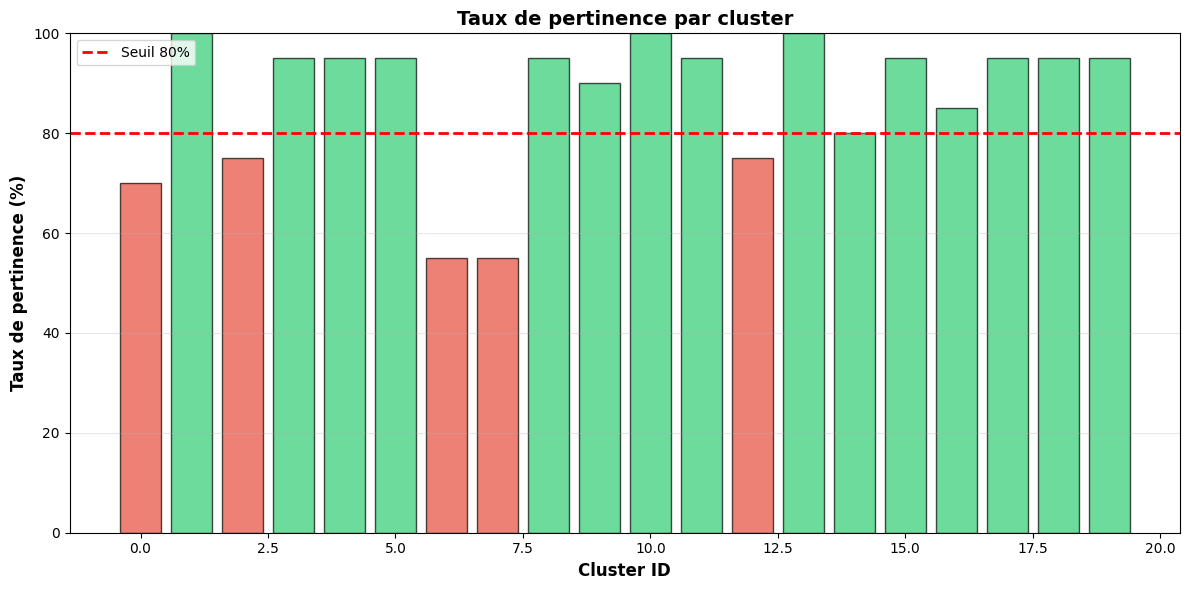


 ANALYSE DES RÉASSIGNATIONS SUGGÉRÉES

 Cluster 0: Transports plus respectueux
   6 propositions mal classées
   Top 3 thèmes suggérés:
     • Énergie renouvelable: 1 (16.7%)
     • Énergie et consommation: 1 (16.7%)
     • Développement durable: 1 (16.7%)

 Cluster 2: Interdiction de la chasse
   5 propositions mal classées
   Top 3 thèmes suggérés:
     • Gestion de la faune: 2 (40.0%)
     • Législation sur les armes: 1 (20.0%)
     • Protection de la faune: 1 (20.0%)

 Cluster 3: Protection de la biodiversité
   1 propositions mal classées
   Top 3 thèmes suggérés:
     • Infrastructure et services publics: 1 (100.0%)

 Cluster 4: Protection de la faune sauvage
   1 propositions mal classées
   Top 3 thèmes suggérés:
     • Consommation durable: 1 (100.0%)

 Cluster 5: Urbanisme durable et vert
   1 propositions mal classées
   Top 3 thèmes suggérés:
     • Gestion financière municipale: 1 (100.0%)

 Cluster 6: Gestion de l'eau pluviale
   9 propositions mal classées
   Top 3 thèm

In [34]:
# ============================================================
# ÉVALUATION LLM AS JUDGE - WORD2VEC
# ============================================================

print("\n" + "="*80)
print(" ÉVALUATION LLM AS JUDGE - WORD2VEC")
print("="*80)

# 1. Évaluer avec vos embeddings Word2Vec (X de shape (n_propositions, 150))
results_w2v_df = evaluate_clusters_w2v(
    df=df,
    X=X,  # Vos vecteurs créés avec proposition_to_vector (150D)
    kmeans_final=kmeans_final,
    best_k=best_k,
    api_key=GROQ_API_KEY,
    sample_size=20
)

# 2. Analyser
cluster_stats_w2v, non_pertinentes_w2v = analyze_results_with_suggestions(results_w2v_df)

# 3. Visualiser
visualize_results(cluster_stats_w2v)

# 4. Analyser les thèmes suggérés
analyze_suggested_themes(results_w2v_df)

# 5. Exporter
results_w2v_df.to_csv('llm_judge_w2v_results_detailed.csv', index=False, encoding='utf-8')

non_pert_w2v = results_w2v_df[results_w2v_df['pertinente'] == 0][
    ['cluster_id', 'assigned_theme', 'proposition', 'suggested_theme']
]
non_pert_w2v.to_csv('llm_judge_w2v_non_pertinentes.csv', index=False, encoding='utf-8')

print("\n Résultats Word2Vec sauvegardés!")